# Я художник, я так вижу, визуализация данных в питоне

# I. Numpy

### Импортируйте NumPy

In [35]:
import numpy as np

np.random.seed(42)

### Создайте одномерный массив размера 10, заполненный нулями и пятым элемент равным 1. Трансформируйте в двумерный массив.

In [30]:
a = np.zeros(10)
a[4] = 1
a = a.reshape(1, 10)
a

array([[0., 0., 0., 0., 1., 0., 0., 0., 0., 0.]])

### Создайте одномерный массив со значениями от 10 до 49 и разверните его (первый элемент становится последним). Найдите в нем все четные элементы.

In [31]:
a = np.arange(10, 50)
a = a[::-1]
a = a[a % 2 == 0]
a

array([48, 46, 44, 42, 40, 38, 36, 34, 32, 30, 28, 26, 24, 22, 20, 18, 16,
       14, 12, 10])

### Создайте двумерный массив 3x3 со значениями от 0 до 8

In [32]:
a = np.arange(0, 9)
a = a.reshape(3, 3)
a

array([[0, 1, 2],
       [3, 4, 5],
       [6, 7, 8]])

### Создайте массив 4x3x2 со случайными значениями. Найти его минимум и максимум.

In [40]:
a = np.random.rand(4, 3, 2)
res = (a.min(), a.max())
print(a)
res

[[[0.54671028 0.18485446]
  [0.96958463 0.77513282]
  [0.93949894 0.89482735]]

 [[0.59789998 0.92187424]
  [0.0884925  0.19598286]
  [0.04522729 0.32533033]]

 [[0.38867729 0.27134903]
  [0.82873751 0.35675333]
  [0.28093451 0.54269608]]

 [[0.14092422 0.80219698]
  [0.07455064 0.98688694]
  [0.77224477 0.19871568]]]


(np.float64(0.045227288910538066), np.float64(0.9868869366005173))

### Создайте два двумерных массива размерами 6x4 и 4x3 и произведите их матричное умножение. 

In [42]:
a = np.random.rand(6, 4)
b = np.random.rand(4, 3)

a.dot(b)

array([[0.19825998, 0.4789245 , 0.59723284],
       [0.82236813, 1.7819882 , 2.31656621],
       [0.61699014, 1.50368265, 1.91026986],
       [0.52974805, 1.10124104, 1.73048615],
       [0.67953513, 1.52146297, 1.56145841],
       [0.37361416, 0.78339337, 0.83418378]])

### Создайте случайный двумерный массив 7x7, найти у него среднее и стандартное оклонение. Нормализуйте этот массив.

In [50]:
a = np.random.randint(1, 1000, (7, 7))
print(a)

print("Mean:", a.mean())
print("Std:", a.std())

a = (a - a.mean()) / a.std()
a

[[144 885  69  99 396  25 948]
 [891 469 484 565 151 144 569]
 [ 39 109 693  42 186 935 398]
 [223 634 133 163 215 733 235]
 [843 658 751 588   9  74 954]
 [492 913 253 230 519 174 653]
 [168 170 393 946 795 634 194]]
Mean: 428.3265306122449
Std: 305.815029312278


array([[-0.92973367,  1.49329963, -1.17497996, -1.07688144, -0.10570615,
        -1.31885778,  1.69930651],
       [ 1.51291933,  0.13300023,  0.18204949,  0.44691548, -0.90684402,
        -0.92973367,  0.45999528],
       [-1.27307847, -1.04418194,  0.86546914, -1.26326862, -0.79239575,
         1.65679715, -0.09916625],
       [-0.67140759,  0.67254206, -0.96570313, -0.86760461, -0.69756719,
         0.99626716, -0.63216818],
       [ 1.35596171,  0.75102087,  1.05512626,  0.52212434, -1.37117699,
        -1.15863021,  1.71892621],
       [ 0.20820909,  1.58485824, -0.57330907, -0.64851793,  0.29649775,
        -0.83163516,  0.73467112],
       [-0.85125486, -0.84471496, -0.11551601,  1.69276661,  1.19900408,
         0.67254206, -0.76623615]])

# II. Pandas

### Импортируйте: pandas, matplotlib, seaborn

In [3]:
import pandas as pd
import seaborn as sns
from matplotlib.pyplot import plot 

### Загрузите датасет Tips из набора датасетов seaborn

In [4]:
dataset = sns.load_dataset("tips")

### Посмотрите на первые 5 строчек

In [15]:
dataset.head(5)

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


### Узнайте сколько всего строчек и колонок в данных

In [5]:
dataset.shape

(244, 7)

### Проверьте есть ли пропуски в данных

In [61]:
dataset[dataset.isna().any(axis=1)]

,total_bill,tip,sex,smoker,day,time,size


### Посмотрите на распределение числовых признаков

In [60]:
dataset.describe()

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


### Найдите максимальное значение 'total_bill'

In [7]:
max(dataset["total_bill"])

50.81

### Найдите количество курящих людей

In [86]:
len(dataset[dataset["smoker"] == "Yes"])

93

### Узнайте какой средний 'total_bill' в зависимости от 'day'

In [62]:
dataset.groupby("day", observed=True)["total_bill"].mean()

day
Thur    17.682742
Fri     17.151579
Sat     20.441379
Sun     21.410000
Name: total_bill, dtype: float64

### Отберите строчки с 'total_bill' больше медианы и узнайте какой средний 'tip' в зависимости от 'sex'

In [89]:
a = dataset[dataset["total_bill"] > dataset["total_bill"].median()]
print(dataset["total_bill"].median(), a)
a.groupby("sex", observed=True)["tip"].mean()

17.795      total_bill   tip     sex smoker   day    time  size
2         21.01  3.50    Male     No   Sun  Dinner     3
3         23.68  3.31    Male     No   Sun  Dinner     2
4         24.59  3.61  Female     No   Sun  Dinner     4
5         25.29  4.71    Male     No   Sun  Dinner     4
7         26.88  3.12    Male     No   Sun  Dinner     4
..          ...   ...     ...    ...   ...     ...   ...
239       29.03  5.92    Male     No   Sat  Dinner     3
240       27.18  2.00  Female    Yes   Sat  Dinner     2
241       22.67  2.00    Male    Yes   Sat  Dinner     2
242       17.82  1.75    Male     No   Sat  Dinner     2
243       18.78  3.00  Female     No  Thur  Dinner     2

[122 rows x 7 columns]


sex
Male      3.756404
Female    3.663939
Name: tip, dtype: float64

### Преобразуйте признак 'smoker' в бинарный (0-No, 1-Yes)

In [91]:
a = dataset.copy()
b = dataset.copy()

a["smoker"] = a["smoker"].apply(lambda is_smoker: 1 if is_smoker == "Yes" else 0)
b["smoker"] = b["smoker"].map({"No": 0, "Yes": 1})

print(b)
a

     total_bill   tip     sex smoker   day    time  size
0         16.99  1.01  Female      0   Sun  Dinner     2
1         10.34  1.66    Male      0   Sun  Dinner     3
2         21.01  3.50    Male      0   Sun  Dinner     3
3         23.68  3.31    Male      0   Sun  Dinner     2
4         24.59  3.61  Female      0   Sun  Dinner     4
..          ...   ...     ...    ...   ...     ...   ...
239       29.03  5.92    Male      0   Sat  Dinner     3
240       27.18  2.00  Female      1   Sat  Dinner     2
241       22.67  2.00    Male      1   Sat  Dinner     2
242       17.82  1.75    Male      0   Sat  Dinner     2
243       18.78  3.00  Female      0  Thur  Dinner     2

[244 rows x 7 columns]


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,0,Sun,Dinner,2
1,10.34,1.66,Male,0,Sun,Dinner,3
2,21.01,3.50,Male,0,Sun,Dinner,3
3,23.68,3.31,Male,0,Sun,Dinner,2
4,24.59,3.61,Female,0,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,0,Sat,Dinner,3
240,27.18,2.00,Female,1,Sat,Dinner,2
241,22.67,2.00,Male,1,Sat,Dinner,2
242,17.82,1.75,Male,0,Sat,Dinner,2


# III. Visualization

### Постройте гистограмму распределения признака 'total_bill'

<Axes: >

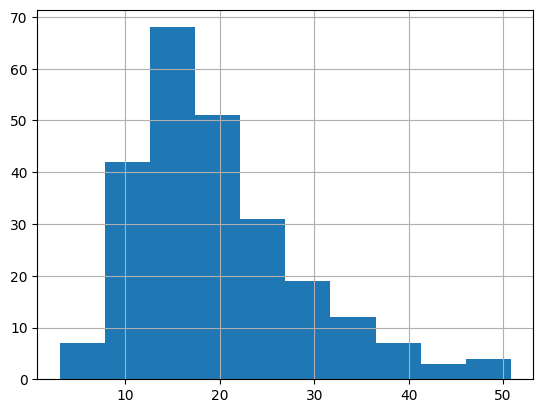

In [6]:
import matplotlib.pyplot as plt

dataset["total_bill"].hist()

### Постройте scatterplot, представляющий взаимосвязь между признаками 'total_bill' и 'tip'

c:\Developments\Python\CUDAIpynbs\.cuda_venv\Lib\site-packages\pandas\plotting\_matplotlib\core.py:1351: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  scatter = ax.scatter(


<Axes: xlabel='total_bill', ylabel='tip'>

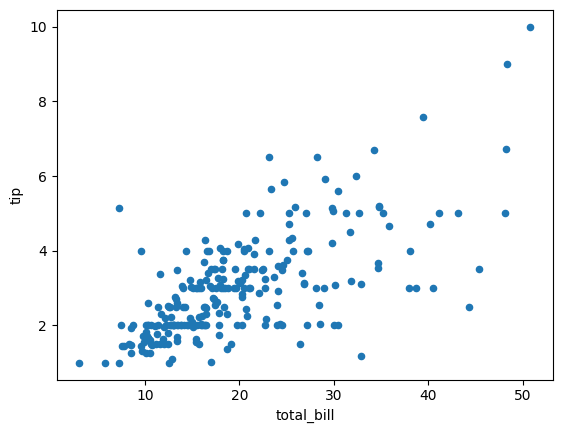

In [7]:
dataset.plot.scatter(x="total_bill", y="tip", colormap="Accent")

### Постройте pairplot

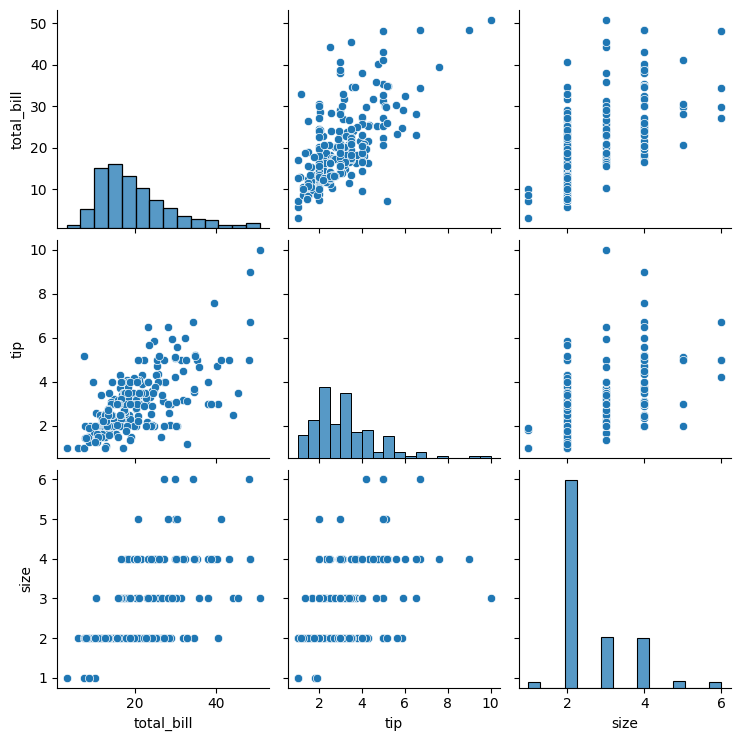

In [8]:
import seaborn as sns

sns.pairplot(dataset)

### Постройте график взаимосвязи между признаками 'total_bill' и 'day'

<Axes: xlabel='total_bill', ylabel='day'>

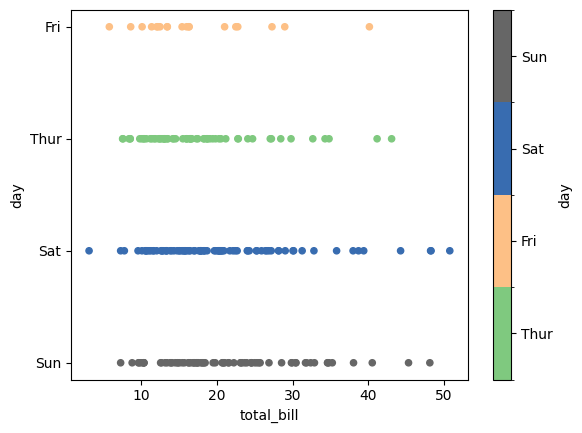

In [10]:
dataset.plot.scatter(x="total_bill", y="day", c="day", colormap="Accent")

### Постройте две гистограммы распределения признака 'tip' в зависимости от категорий 'time'

C:\Users\DeveloperStation\AppData\Local\Temp\ipykernel_5772\221593349.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dataset.plot.hist(column=["tip"], by="time")
C:\Users\DeveloperStation\AppData\Local\Temp\ipykernel_5772\221593349.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dataset.plot.hist(column=["tip"], by="time")
C:\Users\DeveloperStation\AppData\Local\Temp\ipykernel_5772\221593349.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future defa

array([<Axes: title={'center': 'Dinner'}, ylabel='Frequency'>,
       <Axes: title={'center': 'Lunch'}, ylabel='Frequency'>],
      dtype=object)

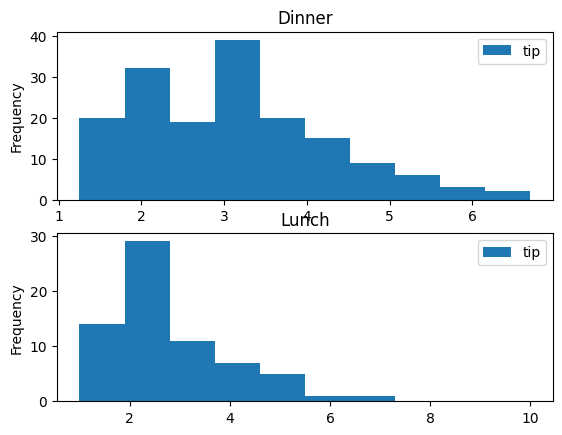

In [14]:
dataset.plot.hist(column=["tip"], by="time")

### Постройте два графика scatterplot, представляющих взаимосвязь между признаками 'total_bill' и 'tip' один для Male, другой для Female и раскрасьте точки в зависимоти от признака 'smoker'

<Axes: title={'center': 'Female'}, xlabel='total_bill', ylabel='tip'>

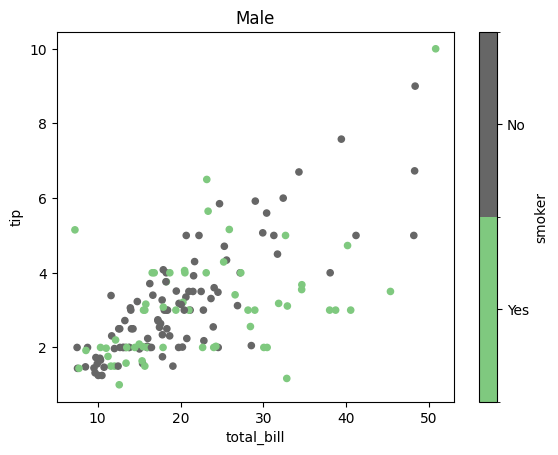

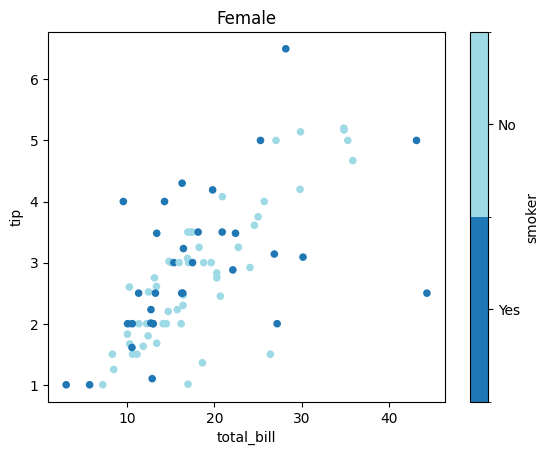

In [134]:
male = dataset[dataset["sex"] == "Male"]
female = dataset[dataset["sex"] == "Female"]

male.plot.scatter(x="total_bill", y="tip", c="smoker", colormap="Accent", title="Male")
female.plot.scatter(x="total_bill", y="tip", c="smoker", colormap="tab20", title="Female")

## Сделайте выводы по анализу датасета и построенным графикам. По желанию можете продолжить анализ данных и также отразить это в выводах.

In [ ]:
# ВАШ КОД ЗДЕСЬ